# Bank Customer Churn Prediction & Retention Analytics System

## 04 — Baseline Machine Learning Models

### Objective

This notebook establishes baseline machine learning models for predicting
customer churn using the feature-engineered banking customer dataset.

The models evaluated are:

- Naive majority-class baseline
- Logistic Regression
- Random Forest
- XGBoost

### Evaluation

Models will be evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC
- Confusion Matrix

Because this is a customer retention problem, particular attention will
be given to recall and PR-AUC. Missing a genuine churner represents a
potential missed retention opportunity.

The best baseline model will be carried forward for optimization on Day 6.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [3]:
PROJECT_ROOT = Path.cwd().parent

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_PATH = PROJECT_ROOT / "models"
REPORTS_PATH = PROJECT_ROOT / "reports"

MODELS_PATH.mkdir(exist_ok=True)
REPORTS_PATH.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\balle\customer-churn-prediction-retention-analytics


In [4]:
file_path = DATA_PROCESSED / "churn_modeling_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 15)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,BalanceStatus,ActivityStatus,AgeActivity
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,36-45,Zero Balance,Active,36-45_Active
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,36-45,Positive Balance,Active,36-45_Active
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,36-45,Positive Balance,Inactive,36-45_Inactive
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,36-45,Zero Balance,Inactive,36-45_Inactive
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,36-45,Positive Balance,Active,36-45_Active


In [5]:
X = df.drop(columns=["Exited"])
y = df["Exited"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 14)
y shape: (10000,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training:", X_train.shape)
print("Test:", X_test.shape)

Training: (8000, 14)
Test: (2000, 14)


In [10]:
preprocessor_path = MODELS_PATH / "preprocessor.joblib"

preprocessor = joblib.load(preprocessor_path)

print("Preprocessor loaded successfully.")

Preprocessor loaded successfully.


In [12]:
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training:", X_train_processed.shape)
print("Processed test:", X_test_processed.shape)

Processed training: (8000, 31)
Processed test: (2000, 31)


In [13]:
majority_class = y_train.mode()[0]

naive_predictions = np.full(
    len(y_test),
    majority_class
)

print("Majority class:", majority_class)
print(
    "Naive accuracy:",
    round(accuracy_score(y_test, naive_predictions), 4)
)

Majority class: 0
Naive accuracy: 0.7965


In [14]:
print(
    "Naive churn recall:",
    round(
        recall_score(
            y_test,
            naive_predictions,
            zero_division=0
        ),
        4
    )
)

Naive churn recall: 0.0


## Naive Baseline

A majority-class baseline predicts every customer as retained.

Although this produces approximately 79.65% accuracy, it identifies none
of the actual churned customers. Its churn recall is therefore 0%.

This demonstrates why accuracy alone is insufficient for evaluating a
customer churn prediction system.

In [15]:
def evaluate_model(model_name, y_true, y_pred, y_probability):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_true,
            y_probability
        ),
        "PR_AUC": average_precision_score(
            y_true,
            y_probability
        )
    }

In [16]:
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

In [17]:
logistic_model.fit(
    X_train_processed,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [18]:
logistic_pred = logistic_model.predict(
    X_test_processed
)

logistic_probability = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

In [20]:
logistic_results = evaluate_model(
    "Logistic Regression",
    y_test,
    logistic_pred,
    logistic_probability
)

logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.7845,
 'Precision': 0.4806451612903226,
 'Recall': 0.7321867321867321,
 'F1': 0.5803310613437196,
 'ROC_AUC': 0.850580935326698,
 'PR_AUC': 0.6945529198878357}

In [21]:
print(
    classification_report(
        y_test,
        logistic_pred,
        target_names=["Stayed", "Churned"]
    )
)

              precision    recall  f1-score   support

      Stayed       0.92      0.80      0.86      1593
     Churned       0.48      0.73      0.58       407

    accuracy                           0.78      2000
   macro avg       0.70      0.77      0.72      2000
weighted avg       0.83      0.78      0.80      2000



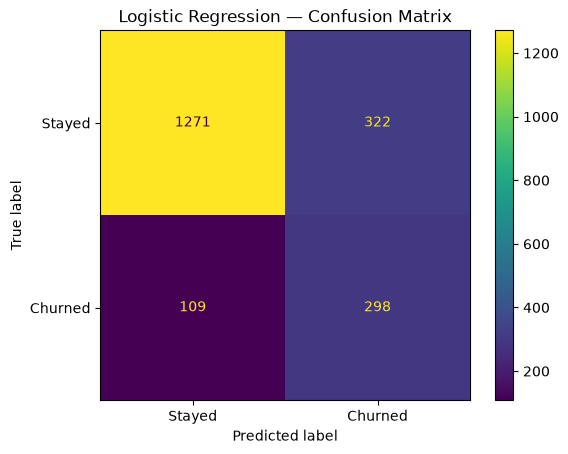

In [22]:
cm = confusion_matrix(
    y_test,
    logistic_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"]
)

disp.plot()
plt.title("Logistic Regression — Confusion Matrix")
plt.show()

In [23]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [24]:
random_forest_model.fit(
    X_train_processed,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [25]:
rf_pred = random_forest_model.predict(
    X_test_processed
)

rf_probability = random_forest_model.predict_proba(
    X_test_processed
)[:, 1]

In [26]:
rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_probability
)

rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.843,
 'Precision': 0.6131386861313869,
 'Recall': 0.6191646191646192,
 'F1': 0.6161369193154034,
 'ROC_AUC': 0.8475609662050341,
 'PR_AUC': 0.6576624124062486}

In [27]:
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["Stayed", "Churned"]
    )
)

              precision    recall  f1-score   support

      Stayed       0.90      0.90      0.90      1593
     Churned       0.61      0.62      0.62       407

    accuracy                           0.84      2000
   macro avg       0.76      0.76      0.76      2000
weighted avg       0.84      0.84      0.84      2000



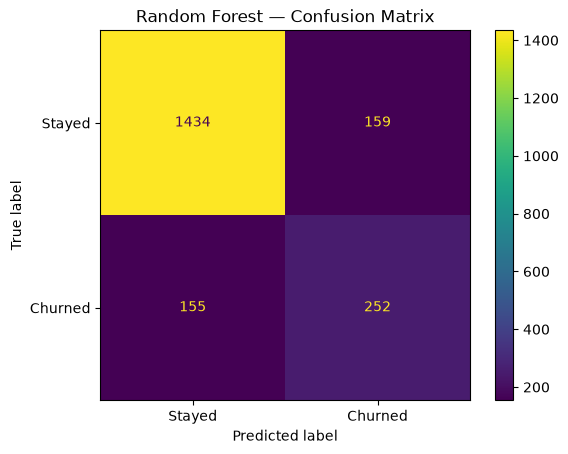

In [28]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"]
)

disp.plot()
plt.title("Random Forest — Confusion Matrix")
plt.show()

In [29]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [30]:
xgb_model.fit(
    X_train_processed,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [31]:
xgb_pred = xgb_model.predict(
    X_test_processed
)

xgb_probability = xgb_model.predict_proba(
    X_test_processed
)[:, 1]

In [32]:
xgb_results = evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_probability
)

xgb_results

{'Model': 'XGBoost',
 'Accuracy': 0.8695,
 'Precision': 0.7786259541984732,
 'Recall': 0.5012285012285013,
 'F1': 0.6098654708520179,
 'ROC_AUC': 0.8653723060502723,
 'PR_AUC': 0.7162431553182309}

In [33]:
print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=["Stayed", "Churned"]
    )
)

              precision    recall  f1-score   support

      Stayed       0.88      0.96      0.92      1593
     Churned       0.78      0.50      0.61       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.77      2000
weighted avg       0.86      0.87      0.86      2000



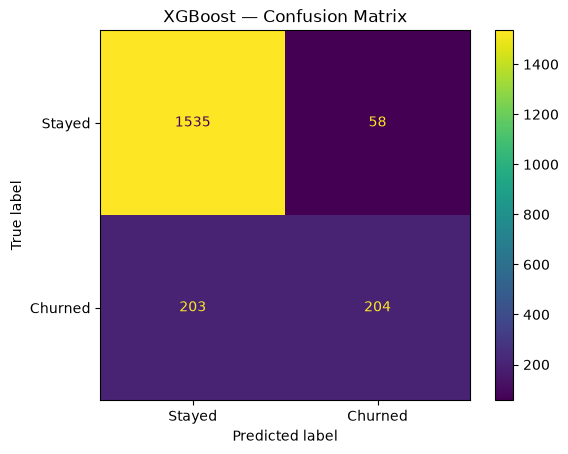

In [34]:
cm = confusion_matrix(
    y_test,
    xgb_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"]
)

disp.plot()
plt.title("XGBoost — Confusion Matrix")
plt.show()

In [36]:
results = pd.DataFrame([
    {
        "Model": "Naive Baseline",
        "Accuracy": accuracy_score(
            y_test,
            naive_predictions
        ),
        "Precision": precision_score(
            y_test,
            naive_predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            naive_predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            naive_predictions,
            zero_division=0
        ),
        "ROC_AUC": np.nan,
        "PR_AUC": np.nan
    },
    logistic_results,
    rf_results,
    xgb_results
])

results.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Naive Baseline,0.7965,0.0000,0.0000,0.0000,NaN,NaN
1,Logistic Regression,0.7845,0.4806,0.7322,0.5803,0.8506,0.6946
2,Random Forest,0.8430,0.6131,0.6192,0.6161,0.8476,0.6577
3,XGBoost,0.8695,0.7786,0.5012,0.6099,0.8654,0.7162


In [37]:
results.sort_values(
    by="PR_AUC",
    ascending=False
).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
3,XGBoost,0.8695,0.7786,0.5012,0.6099,0.8654,0.7162
1,Logistic Regression,0.7845,0.4806,0.7322,0.5803,0.8506,0.6946
2,Random Forest,0.8430,0.6131,0.6192,0.6161,0.8476,0.6577
0,Naive Baseline,0.7965,0.0000,0.0000,0.0000,NaN,NaN


In [38]:
results.sort_values(
    by="Recall",
    ascending=False
).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
1,Logistic Regression,0.7845,0.4806,0.7322,0.5803,0.8506,0.6946
2,Random Forest,0.8430,0.6131,0.6192,0.6161,0.8476,0.6577
3,XGBoost,0.8695,0.7786,0.5012,0.6099,0.8654,0.7162
0,Naive Baseline,0.7965,0.0000,0.0000,0.0000,NaN,NaN


In [39]:
results.sort_values(
    by="F1",
    ascending=False
).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
2,Random Forest,0.8430,0.6131,0.6192,0.6161,0.8476,0.6577
3,XGBoost,0.8695,0.7786,0.5012,0.6099,0.8654,0.7162
1,Logistic Regression,0.7845,0.4806,0.7322,0.5803,0.8506,0.6946
0,Naive Baseline,0.7965,0.0000,0.0000,0.0000,NaN,NaN


In [40]:
threshold_results = []

for threshold in np.arange(0.20, 0.71, 0.05):

    predictions = (
        xgb_probability >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df.round(4)

,Threshold,Precision,Recall,F1
0,0.20,0.4976,0.7543,0.5996
1,0.25,0.5560,0.7199,0.6274
2,0.30,0.6000,0.6634,0.6301
3,0.35,0.6512,0.6192,0.6348
4,0.40,0.6824,0.5700,0.6212
5,0.45,0.7300,0.5381,0.6195
6,0.50,0.7786,0.5012,0.6099
7,0.55,0.8150,0.4545,0.5836
8,0.60,0.8469,0.4079,0.5506
9,0.65,0.8764,0.3833,0.5333


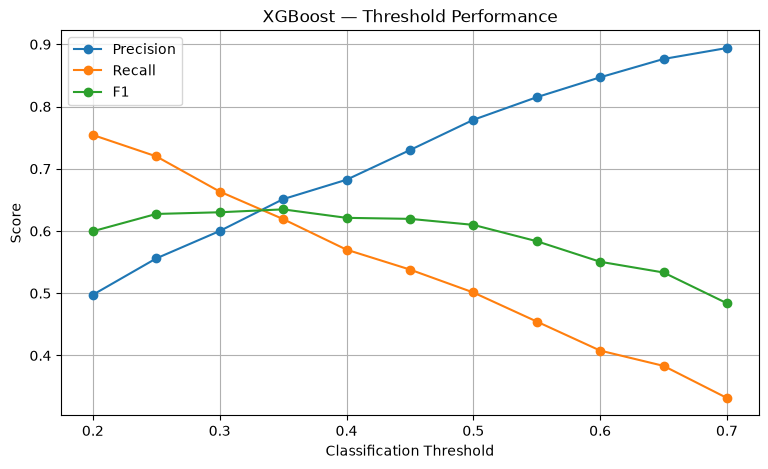

In [41]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"

)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("XGBoost — Threshold Performance")
plt.legend()
plt.grid(True)
plt.show()

In [42]:
joblib.dump(
    logistic_model,
    MODELS_PATH / "logistic_regression_baseline.joblib"
)

joblib.dump(
    random_forest_model,
    MODELS_PATH / "random_forest_baseline.joblib"
)

joblib.dump(
    xgb_model,
    MODELS_PATH / "xgboost_baseline.joblib"
)

print("Baseline models saved successfully.")

Baseline models saved successfully.


In [43]:
results.to_csv(
    REPORTS_PATH / "baseline_model_results.csv",
    index=False
)

threshold_df.to_csv(
    REPORTS_PATH / "xgboost_threshold_analysis.csv",
    index=False
)

print("Evaluation results saved.")

Evaluation results saved.


In [49]:
print("=== SAVED MODELS ===")

for file in [
    "logistic_regression_baseline.joblib",
    "random_forest_baseline.joblib",
    "xgboost_baseline.joblib"
]:
    path = MODELS_PATH / file
    print(file, "→", path.exists())

=== SAVED MODELS ===
logistic_regression_baseline.joblib → True
random_forest_baseline.joblib → True
xgboost_baseline.joblib → True


## Baseline Model Findings

Three machine learning models were evaluated against a naive majority-class
baseline.

The naive baseline achieved approximately 79.65% accuracy by predicting
all customers as retained, but its churn recall was 0%. This demonstrates
that accuracy alone is not an appropriate metric for the retention use case.

Logistic Regression achieved the highest churn recall at 73.22%, indicating
that it identified the largest proportion of actual churners. However, its
precision was relatively low at 48.06%, resulting in a higher number of
false-positive retention alerts.

Random Forest achieved the highest F1-score at the default classification
threshold, with an F1-score of 61.61%.

XGBoost achieved the strongest overall discrimination, with a ROC-AUC of
0.8654 and PR-AUC of 0.7162. It also achieved the highest default-threshold
precision at 77.86%.

Threshold analysis showed that reducing the XGBoost classification
threshold from 0.50 to 0.35 increased recall from 50.12% to 61.92% and
improved F1-score from 60.99% to 63.48%.

The baseline results indicate that XGBoost is a strong candidate for
optimization, while Logistic Regression provides a useful high-recall
benchmark. Final model selection and operating-threshold decisions will
be performed after hyperparameter optimization.

In [50]:
results.to_csv(
    REPORTS_PATH / "baseline_model_results.csv",
    index=False
)

threshold_df.to_csv(
    REPORTS_PATH / "xgboost_threshold_analysis.csv",
    index=False
)

print("Baseline evaluation reports saved.")

Baseline evaluation reports saved.
